# INFO-6147-(01)-26W Deep Learning with Pytorch

## Project:

**Student Name:** Yun-Jiung Wang

**Student Number:** 1256222

**Date:** March 30th, 2026

**Description:**

This project is aim to allow user upload the photos of food and describe what the food tastes like. It will be helpful when traveling or when people wants to try international food, but not having a person to explain to you what that is.
Here comes this AI project, to assist people on observing new foods.

## Setup Environment

In [1]:
!pip install datasets gradio streamlit groq pyngrok

# dlownload Cloudflare tunnle tool
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 149.0 MB/s eta 0:00:00
--2026-04-05 21:20:16--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb [following]
--2026-04-05 21:20:17--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64.deb
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/ec689fe1-d727-4ebd-bbc3-5967730ab5

## Import Libs

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.datasets import Food101
from torch.utils.data import Dataset, Subset,DataLoader

from datasets import load_dataset

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import io
from tqdm import tqdm

from google.colab import userdata,runtime,drive # Store the API via Colab Secret
import zipfile
import os

## Check Device

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


## Setup Hyperparameters

In [4]:
EPOCHS=50
BATCH_SIZE = 256
LEARNING_RATE=0.0001
NUM_WORKERS= 12
PATIENCE = 10 # early stop


DATA_PATH="/data"

## Load Dataset (Full)

In [5]:
# Transformer

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset (train and test)
train_dataset = datasets.Food101(root=DATA_PATH, split='train', download=True, transform=train_transform)

test_dataset = datasets.Food101(root=DATA_PATH, split='test', download=True, transform=test_transform)

100%|██████████| 5.00G/5.00G [03:58<00:00, 20.9MB/s]


## Define Food Types for subset

In [6]:
select_food_list = sorted( [
     # --- Asia ---
    'bibimbap', 'gyoza', 'sashimi', 'pad_thai', 'pho',
    'miso_soup', 'edamame', 'spring_rolls', 'sushi', 'dumplings',
    'hummus', 'falafel', 'baklava', 'chicken_curry', 'fried_rice',

    # --- Lattino ---
    'tacos', 'enchiladas', 'guacamole', 'ceviche', 'nachos',

    # --- Classic ---
    'pizza', 'hamburger', 'hot_dog', 'steak', 'french_fries',
    'grilled_salmon', 'spaghetti_bolognese', 'lasagna', 'club_sandwich',

    # --- Hot in Social Media ---
    'tiramisu', 'cheesecake', 'macarons', 'donuts', 'waffles',
    'pancakes', 'ice_cream', 'apple_pie', 'strawberry_shortcake',

    # --- seafoods ---
    'mussels', 'oysters'
]
)

# Create Mapping dictionary
label_to_name = {i: name for i, name in enumerate(select_food_list)}
print(label_to_name)

class_to_idx = {cls_name: i for i, cls_name in enumerate(select_food_list)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

In [7]:
print(f"len of selected list:{len(select_food_list)}")


40

## Create Filter Class

In [ ]:
class FilteredFood101(Dataset):
    def __init__(self, dataset, selected_classes, transform=None):
        self.dataset = dataset
        self.transform = transform

        self.selected_classes = selected_classes
        self.class_to_idx = {cls: i for i, cls in enumerate(selected_classes)}

        self.filtered_indices = []

        for i in range(len(dataset)):
            label = dataset._labels[i]
            class_name = dataset.classes[label]

            if class_name in self.selected_classes:
                self.filtered_indices.append(i)

    def __len__(self):
        return len(self.filtered_indices)

    def __getitem__(self, idx):
        real_idx = self.filtered_indices[idx]
        img, label = self.dataset[real_idx]

        class_name = self.dataset.classes[label]
        new_label = self.class_to_idx[class_name]  # ⭐ rebuild label

        if self.transform:
            img = self.transform(img)

        return img, new_label

## Create Subset

In [8]:
filtered_train = FilteredFood101(train_dataset, select_food_list)
filtered_test = FilteredFood101(test_dataset, select_food_list)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(len(filtered_train), len(filtered_test))

train_loader = DataLoader(filtered_train, batch_size=32, shuffle=True,pin_memory=True)
test_loader = DataLoader(filtered_test, batch_size=32, shuffle=False)

labels = [label for _, label in filtered_train]
print(min(labels), max(labels))

num_classes = max(labels)+1
print(f"num of classes: {num_classes}, max lavel:{max(labels)}")

29250 9750
0 39
num of classes: 40, max lavel:39


## Confirm Subsets

## Build the model

In [9]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
print(f"num_classes:{num_classes}")
# model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# model.fc = nn.Sequential(
#     nn.Linear(model.fc.in_features, 512),
#     nn.BatchNorm1d(512),
#     nn.ReLU(),                # activate param
#     nn.Dropout(0.3),          # drop off 30%
#     nn.Linear(512, num_classes) # output classes
# )

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024), # larger to 1024
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.4),           # prevernt overfitting
    nn.Linear(1024, 512),      # add layer
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Linear(512, num_classes)         #final classes
)

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE,weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 242MB/s]


num_classes:40


## Define the Model

In [10]:
class FoodClassifier:
    def __init__(self, model, train_loader, test_loader, criterion, optimizer, device, patience=PATIENCE):
        self.model = model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')

        # History
        self.history = {
            'train_loss': [], 'train_acc': [],
            'test_loss': [], 'test_acc': [],
            'test_f1': [], 'lr': []
        }

    def train_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(self.train_loader, desc="[Train]", leave=False)
        for images, labels in pbar:
            images, labels = images.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        return running_loss / len(self.train_loader), 100. * correct / total

    def validate(self):
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                # record F1
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_loss = running_loss / len(self.test_loader)
        acc = 100. * correct / total
        f1 = f1_score(all_labels, all_preds, average='macro')
        return avg_loss, acc, f1

    def run_training(self, num_epochs, save_path):
        print(f"Training started (ResNet-50 / 40 Classes)")
        print(f"Save destination: {save_path}\n")

        for epoch in range(num_epochs):
            t_loss, t_acc = self.train_epoch()
            v_loss, v_acc, v_f1 = self.validate()

            # record current learning rate
            current_lr = self.optimizer.param_groups[0]['lr']

            self.history['train_loss'].append(t_loss)
            self.history['train_acc'].append(t_acc)
            self.history['test_loss'].append(v_loss)
            self.history['test_acc'].append(v_acc)
            self.history['test_f1'].append(v_f1)
            self.history['lr'].append(current_lr)

            print(f"Epoch {epoch+1:02d}/{num_epochs} | "
                  f"Train Acc: {t_acc:.2f}% | Test Acc: {v_acc:.2f}% | "
                  f"F1: {v_f1:.4f} | LR: {current_lr:.2e}")

            # --- Early Stopping Logic ---
            if v_loss < self.best_loss:
                self.best_loss = v_loss
                self.counter = 0
                torch.save(self.model.state_dict(), save_path)
                print(f"New best model saved! (Loss: {v_loss:.4f})")
            else:
                self.counter += 1
                if self.counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}.")
                    break

        print(f"\n✅ Training complete. Loading best weights for final data collection...")

        # Training complete; load the most powerful version to output the final prediction results.
        self.model.load_state_dict(torch.load(save_path))
        final_y_true, final_y_pred = self._get_final_predictions()

        return self.history, final_y_true, final_y_pred

    def _get_final_predictions(self):
        self.model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for images, labels in self.test_loader:
                images = images.to(self.device)
                outputs = self.model(images)
                _, predicted = outputs.max(1)
                y_true.extend(labels.numpy())
                y_pred.extend(predicted.cpu().numpy())
        return y_true, y_pred

## Model Evaluation

In [14]:
class ModelEvaluator:
    """
    Evaluate the model performance.
    """
    def __init__(self, history, y_true, y_pred, class_names):
        self.history = history
        self.y_true = np.array(y_true)
        self.y_pred = np.array(y_pred)
        self.class_names = class_names

    def plot_comprehensive_metrics(self):
        """1. Accuracy, Loss, Learning Rate, F1"""
        fig, axs = plt.subplots(2, 2, figsize=(16, 12))
        epochs = range(1, len(self.history['train_loss']) + 1)

        #  Accuracy Rate
        axs[0, 0].plot(epochs, self.history['train_acc'], 'g-o', label='Train Acc', markersize=4)
        axs[0, 0].plot(epochs, self.history['test_acc'], 'm-s', label='Test Acc', markersize=4)
        axs[0, 0].set_title('Accuracy Trend', fontsize=14)
        axs[0, 0].set_xlabel('Epochs')
        axs[0, 0].set_ylabel('Accuracy (%)')
        axs[0, 0].grid(True, linestyle='--', alpha=0.6)
        axs[0, 0].legend()

        # Loss Curve
        axs[0, 1].plot(epochs, self.history['train_loss'], 'b-o', label='Train Loss', markersize=4)
        axs[0, 1].plot(epochs, self.history['test_loss'], 'r-s', label='Test Loss', markersize=4)
        axs[0, 1].set_title('Loss Convergence', fontsize=14)
        axs[0, 1].set_xlabel('Epochs')
        axs[0, 1].set_ylabel('Loss Value')
        axs[0, 1].grid(True, linestyle='--', alpha=0.6)
        axs[0, 1].legend()

        # Learning Rate Schedule
        if 'lr' in self.history and len(self.history['lr']) > 0:
            axs[1, 0].plot(epochs, self.history['lr'], 'k-x', label='Learning Rate')
            axs[1, 0].set_yscale('log')
            axs[1, 0].set_title('LR Decay Schedule (Log Scale)', fontsize=14)
            axs[1, 0].set_xlabel('Epochs')
            axs[1, 0].set_ylabel('LR')
            axs[1, 0].grid(True, which="both", ls="-", alpha=0.3)
        else:
            axs[1, 0].text(0.5, 0.5, 'No LR Data', ha='center')

        # F1-Score (Evaluation)
        if 'test_f1' in self.history and len(self.history['test_f1']) > 0:
            axs[1, 1].plot(epochs, self.history['test_f1'], 'c-^', label='Test F1 (Macro)')
            axs[1, 1].set_title('F1-Score (Model Balance)', fontsize=14)
            axs[1, 1].set_xlabel('Epochs')
            axs[1, 1].set_ylabel('F1 Score')
            axs[1, 1].grid(True, linestyle='--', alpha=0.6)

        plt.tight_layout()
        plt.show()

    def plot_confusion_matrix(self, figsize=(14, 12)):
        """confusion matrix"""
        cm = confusion_matrix(self.y_true, self.y_pred)
        plt.figure(figsize=figsize)
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                    xticklabels=self.class_names,
                    yticklabels=self.class_names)
        plt.title('Confusion Matrix: Food-40 Classification', fontsize=16)
        plt.ylabel('Actual Food Type')
        plt.xlabel('Predicted Food Type')
        plt.xticks(rotation=45, ha='right')
        plt.show()

    def print_detailed_analysis(self):
        """CLASSIFICATION PERFORMANCE """
        print("\n" + "="*60)
        print("DETAILED CLASSIFICATION PERFORMANCE")
        print("="*60)
        all_labels = list(range(len(self.class_names)))

        report = classification_report(self.y_true, self.y_pred,
                                        target_names=self.class_names,
                                        labels=all_labels,
                                        output_dict=True)

        # The top 5 difficault image to classify
        class_stats = {k: v for k, v in report.items() if k in self.class_names}
        worst_5 = sorted(class_stats.items(), key=lambda x: x[1]['f1-score'])[:5]

        print(f"{'Food Class':<20} | {'F1-Score':<10} | {'Precision':<10} | {'Recall':<10}")
        print("-" * 60)
        for name, stats in worst_5:
            print(f"{name:<20} | {stats['f1-score']:.4f} | {stats['precision']:.4f} | {stats['recall']:.4f}")

        final_f1 = f1_score(self.y_true, self.y_pred, average='macro')
        print(f"Final Macro F1-Score: {final_f1:.4f}")

## Start training

In [12]:
trainer = FoodClassifier(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE
)

my_history,my_y_true, my_y_pred = trainer.run_training(num_epochs=EPOCHS,save_path="/data/food_best.pth")

Training started (ResNet-50 / 40 Classes)
Save destination: /data/food_best.pth



Epoch 01/50 | Train Acc: 44.25% | Test Acc: 55.29% | F1: 0.5632 | LR: 1.00e-03
New best model saved! (Loss: 1.7403)


Epoch 02/50 | Train Acc: 48.93% | Test Acc: 64.34% | F1: 0.6452 | LR: 1.00e-03
New best model saved! (Loss: 1.2870)


Epoch 03/50 | Train Acc: 53.34% | Test Acc: 65.73% | F1: 0.6600 | LR: 1.00e-03
New best model saved! (Loss: 1.2386)


Epoch 04/50 | Train Acc: 58.82% | Test Acc: 66.46% | F1: 0.6646 | LR: 1.00e-03


...

Epoch 06/50 | Train Acc: 61.25% | Test Acc: 70.37% | F1: 0.7027 | LR: 1.00e-03


Epoch 07/50 | Train Acc: 58.56% | Test Acc: 56.94% | F1: 0.5913 | LR: 1.00e-03


Epoch 08/50 | Train Acc: 50.27% | Test Acc: 65.76% | F1: 0.6528 | LR: 1.00e-03


Epoch 09/50 | Train Acc: 56.00% | Test Acc: 76.43% | F1: 0.7632 | LR: 1.00e-03


Epoch 10/50 | Train Acc: 62.14% | Test Acc: 71.27% | F1: 0.7159 | LR: 1.00e-03
Early stopping at epoch 10.

✅ Training complete. Loading best weights for final data collection...


## Show Evaluation

Classes shown in train:Counter({np.int64(2): 250, np.int64(7): 250, np.int64(15): 250, np.int64(3): 250, np.int64(0): 250, np.int64(36): 250, np.int64(23): 250, np.int64(5): 250, np.int64(28): 250, np.int64(11): 250, np.int64(29): 250, np.int64(26): 250, np.int64(38): 250, np.int64(12): 250, np.int64(6): 250, np.int64(34): 250, np.int64(25): 250, np.int64(13): 250, np.int64(10): 250, np.int64(27): 250, np.int64(17): 250, np.int64(37): 250, np.int64(14): 250, np.int64(32): 250, np.int64(1): 250, np.int64(18): 250, np.int64(24): 250, np.int64(21): 250, np.int64(9): 250, np.int64(8): 250, np.int64(22): 250, np.int64(31): 250, np.int64(33): 250, np.int64(20): 250, np.int64(4): 250, np.int64(30): 250, np.int64(35): 250, np.int64(19): 250, np.int64(39): 250})
True Labels:[np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2)]


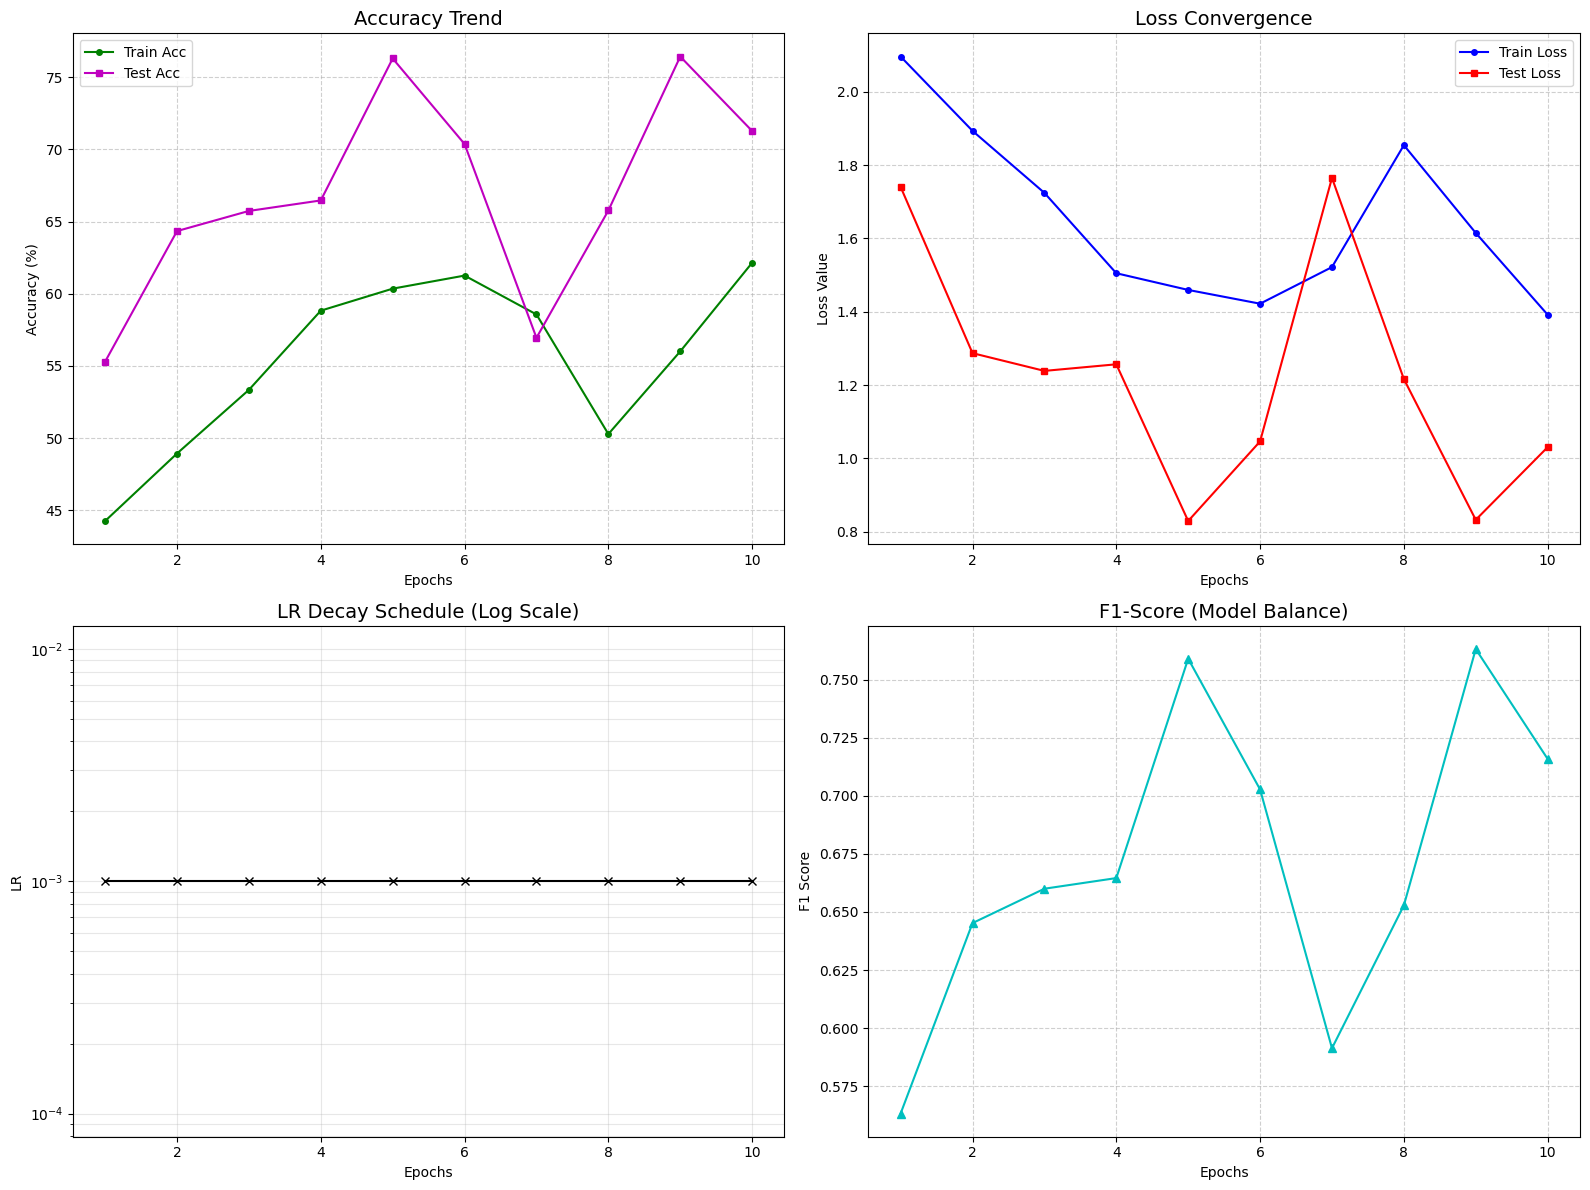

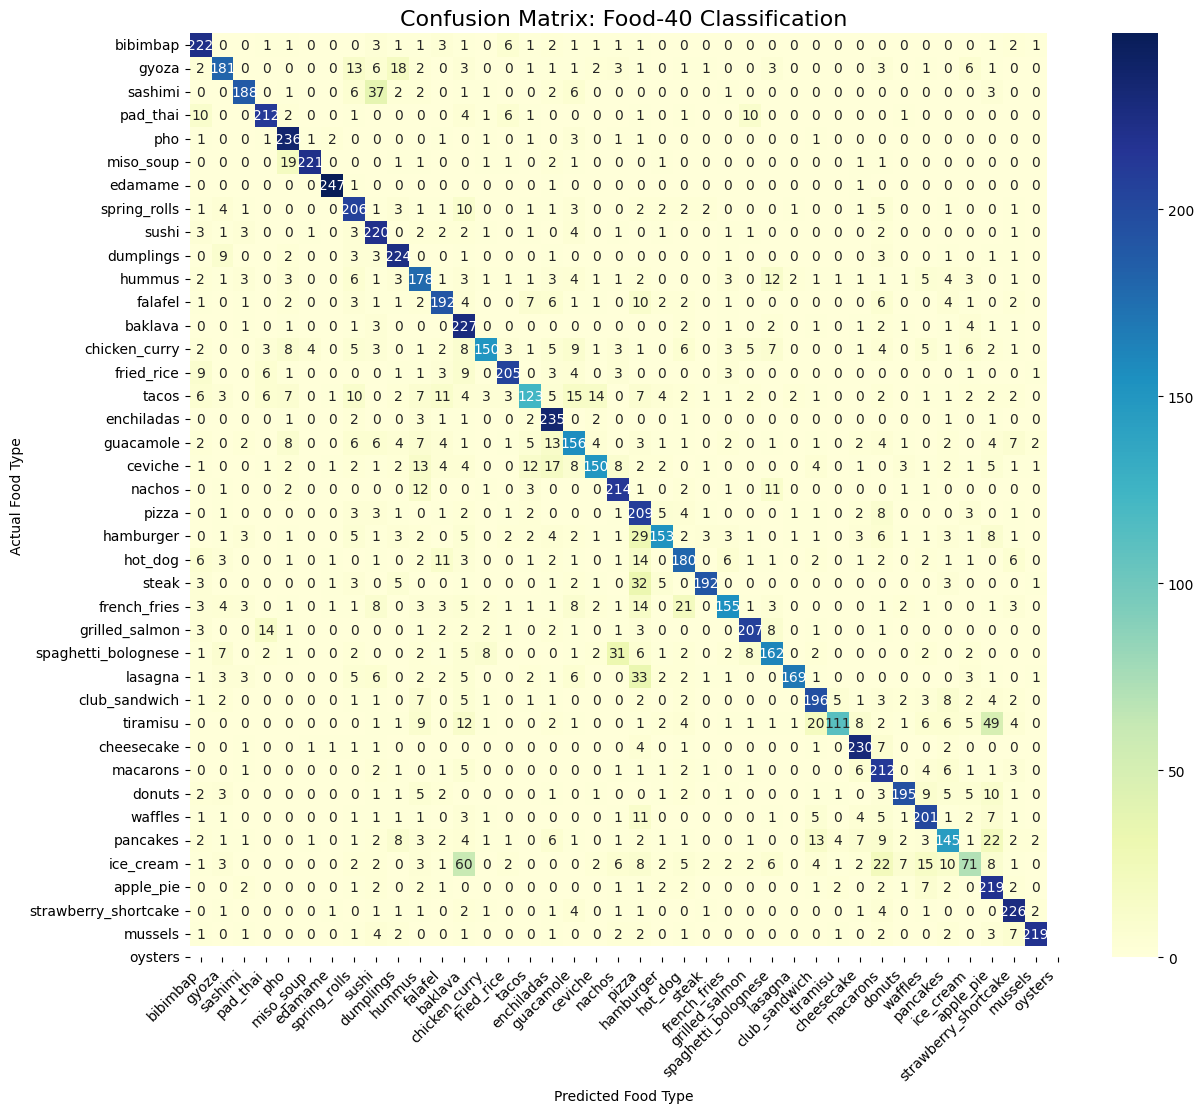


DETAILED CLASSIFICATION PERFORMANCE
Food Class           | F1-Score   | Precision  | Recall    
------------------------------------------------------------
enchiladas           | 0.0000 | 0.0000 | 0.0000
apple_pie            | 0.3827 | 0.5868 | 0.2840
tacos                | 0.5871 | 0.7278 | 0.4920
cheesecake           | 0.5904 | 0.8810 | 0.4440
ice_cream            | 0.6277 | 0.6840 | 0.5800
Final Macro F1-Score: 0.7590


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [15]:
from collections import Counter

test_counts = Counter(my_y_true)
print(f"Classes shown in train:{test_counts}")

#Print True Lables
print(f"True Labels:{my_y_true[:10]}")

evaluation = ModelEvaluator(
    history=my_history,
    y_true=my_y_true,
    y_pred=my_y_pred,
    class_names=select_food_list
)

#Accuracy, Loss, Learning Rate, F1
evaluation.plot_comprehensive_metrics()

# Confusion Matrix
evaluation.plot_confusion_matrix()

#Detailed Analysis
evaluation.print_detailed_analysis()

## Observation Description

## Conclusion